# **Extracting Information from Legal Documents Using RAG**

## **Objective**

The main objective of this assignment is to process and analyse a collection text files containing legal agreements (e.g., NDAs) to prepare them for implementing a **Retrieval-Augmented Generation (RAG)** system. This involves:

* Understand the Cleaned Data : Gain a comprehensive understanding of the structure, content, and context of the cleaned dataset.
* Perform Exploratory Analysis : Conduct bivariate and multivariate analyses to uncover relationships and trends within the cleaned data.
* Create Visualisations : Develop meaningful visualisations to support the analysis and make findings interpretable.
* Derive Insights and Conclusions : Extract valuable insights from the cleaned data and provide clear, actionable conclusions.
* Document the Process : Provide a detailed description of the data, its attributes, and the steps taken during the analysis for reproducibility and clarity.

The ultimate goal is to transform the raw text data into a clean, structured, and analysable format that can be effectively used to build and train a RAG system for tasks like information retrieval, question-answering, and knowledge extraction related to legal agreements.

### **Business Value**  


The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research: <br> Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis: <br> Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring: <br> Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making: <br> Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

## **1. Data Loading, Preparation and Analysis**

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For the above folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### **1.2 Load and Preprocess the data** 

#### Loading libraries

In [ ]:
## The following libraries might be useful
!pip install -q langchain-openai
!pip install -U -q langchain-community
!pip install -U -q langchain-chroma
!pip install -U -q datasets
!pip install -U -q ragas
!pip install -U -q rouge_score
!pip install -U -q rank_bm25

In [4]:
# Import essential libraries
import re
import logging
from pathlib import Path

from langchain_core.documents import Document

try:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
except ImportError:
    ENGLISH_STOP_WORDS = frozenset()

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("rag_legal")


#### **1.2.1** Load all `.txt` files from the folders.

You can utilise document loaders from the options provided by the LangChain community.

Optionally, you can also read the files manually, while ensuring proper handling of encoding issues (e.g., utf-8, latin1). In such case, also store the file content along with metadata (e.g., file name, directory path) for traceability.

In [5]:
# Load the files as documents
CORPUS_DIR = Path("rag_legal/corpus")
DOC_TYPES = ["contractnli", "cuad", "maud", "privacy_qa"]


def load_text_file(file_path: Path) -> str:
    """Read a text file, falling back to latin-1 if utf-8 decoding fails."""
    for encoding in ("utf-8", "latin-1"):
        try:
            return file_path.read_text(encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("utf-8/latin-1", b"", 0, 1, f"Could not decode {file_path}")


raw_documents = []
skipped_files = []

for doc_type in DOC_TYPES:
    folder = CORPUS_DIR / doc_type
    txt_files = sorted(folder.glob("*.txt"))
    for file_path in txt_files:
        try:
            text = load_text_file(file_path)
        except Exception as exc:
            logger.warning("Skipping unreadable file %s: %s", file_path, exc)
            skipped_files.append(str(file_path))
            continue

        if not text.strip():
            logger.warning("Skipping empty file %s", file_path)
            skipped_files.append(str(file_path))
            continue

        raw_documents.append(
            Document(
                page_content=text,
                metadata={
                    "doc_type": doc_type,
                    "file_name": file_path.name,
                    # matches the "file_path" field used in the benchmark JSON files
                    "relative_path": f"{doc_type}/{file_path.name}",
                    "source": str(file_path),
                },
            )
        )

print(f"Loaded {len(raw_documents)} documents across {len(DOC_TYPES)} folders.")
print(f"Skipped {len(skipped_files)} unreadable/empty files.")
for doc_type in DOC_TYPES:
    count = sum(1 for d in raw_documents if d.metadata["doc_type"] == doc_type)
    print(f"  {doc_type}: {count} files")


Loaded 644 documents across 4 folders.
Skipped 0 unreadable/empty files.
  contractnli: 93 files
  cuad: 431 files
  maud: 117 files
  privacy_qa: 3 files


#### **1.2.2** Preprocess the text data to remove noise and prepare it for analysis.

Remove special characters, extra whitespace, and irrelevant content such as email and telephone contact info.
Normalise text (e.g., convert to lowercase, remove stop words).
Handle missing or corrupted data by logging errors and skipping problematic files.

In [6]:
# Clean and preprocess the data
EMAIL_RE = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
# only matches separated digit groups (e.g. 555-123-4567) to avoid mangling
# clause numbers, dates and dollar amounts that are common in legal text
PHONE_RE = re.compile(r"(?<!\d)(?:\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}(?!\d)")
CONTROL_CHARS_RE = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")
REPEATED_PUNCT_RE = re.compile(r"[_\-=*]{4,}")  # page-break / divider artifacts
INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
BLANK_LINES_RE = re.compile(r"\n{3,}")


def clean_text(text: str) -> str:
    """Strip contact info and formatting noise while preserving wording/case/punctuation needed for legal meaning."""
    text = EMAIL_RE.sub(" ", text)
    text = PHONE_RE.sub(" ", text)
    text = CONTROL_CHARS_RE.sub(" ", text)
    text = REPEATED_PUNCT_RE.sub(" ", text)
    text = INLINE_WHITESPACE_RE.sub(" ", text)
    text = BLANK_LINES_RE.sub("\n\n", text)
    return text.strip()


def normalize_for_analysis(text: str) -> str:
    """Lowercase, alphabetic-only, stop-word-free text for EDA (word frequency, TF-IDF) - not used for the RAG corpus itself."""
    tokens = re.findall(r"[a-zA-Z]+", text.lower())
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 1]
    return " ".join(tokens)


documents = []
for doc in raw_documents:
    cleaned = clean_text(doc.page_content)
    if not cleaned:
        logger.warning("Skipping %s: empty after cleaning", doc.metadata["relative_path"])
        skipped_files.append(doc.metadata["source"])
        continue

    new_metadata = dict(doc.metadata)
    new_metadata["char_count"] = len(cleaned)
    new_metadata["normalized_text"] = normalize_for_analysis(cleaned)
    documents.append(Document(page_content=cleaned, metadata=new_metadata))

print(f"Cleaned {len(documents)} documents; {len(skipped_files)} total skipped.")
print("\nSample cleaned document:\n")
print(documents[0].page_content[:500])
print("\nMetadata:", {k: v for k, v in documents[0].metadata.items() if k != "normalized_text"})


Cleaned 644 documents; 0 total skipped.

Sample cleaned document:

MUTUAL NON-DISCLOSURE AGREEMENT
Between
AND
Subject Matter:
Effective Date of Agreement: Period , 2017
for Exchange of Information: , 2017 to
Period of Confidentiality:
THIS AGREEMENT is made as of the Effective Date of Agreement noted above, by and between the above parties.
BACKGROUND:
I. The parties desire to have discussions of or relating to the Subject Matter for the purposes of evaluating a possible business relationship between them (“Purpose”). The parties may extend the Subject Matter 

Metadata: {'doc_type': 'contractnli', 'file_name': '01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'relative_path': 'contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'source': 'rag_legal\\corpus\\contractnli\\01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'char_count': 15296}


### **1.3 Exploratory Data Analysis**

#### **1.3.1** Calculate the average, maximum and minimum document length.

Document length in words:
  Average: 15230.0
  Maximum: 156104 (maud/Contango_Oil_&_Gas_KKR_&_Co.txt)
  Minimum: 219 (cuad/GALACTICOMMTECHNOLOGIESINC_11_07_1997-EX-10.46-WEB HOSTING AGREEMENT.txt)

Document length in characters:
  Average: 97080.1
  Maximum: 984480 (maud/Contango_Oil_&_Gas_KKR_&_Co.txt)
  Minimum: 1391 (cuad/GALACTICOMMTECHNOLOGIESINC_11_07_1997-EX-10.46-WEB HOSTING AGREEMENT.txt)


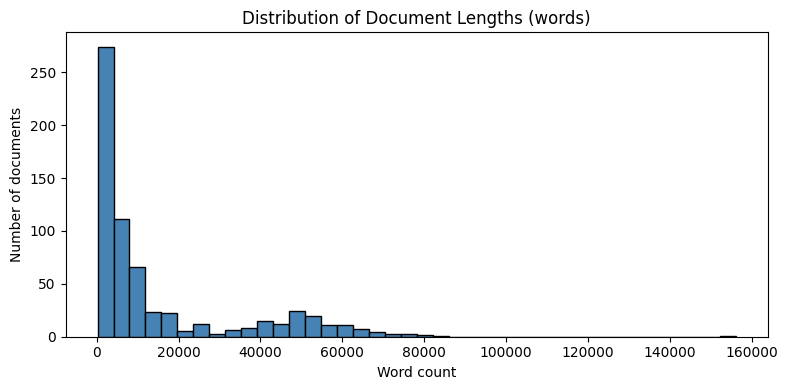

In [7]:
# Calculate the average, maximum and minimum document length.
import numpy as np
import matplotlib.pyplot as plt

doc_lengths_words = [len(doc.page_content.split()) for doc in documents]
doc_lengths_chars = [len(doc.page_content) for doc in documents]

print("Document length in words:")
print(f"  Average: {np.mean(doc_lengths_words):.1f}")
print(f"  Maximum: {np.max(doc_lengths_words)} ({documents[int(np.argmax(doc_lengths_words))].metadata['relative_path']})")
print(f"  Minimum: {np.min(doc_lengths_words)} ({documents[int(np.argmin(doc_lengths_words))].metadata['relative_path']})")

print("\nDocument length in characters:")
print(f"  Average: {np.mean(doc_lengths_chars):.1f}")
print(f"  Maximum: {np.max(doc_lengths_chars)} ({documents[int(np.argmax(doc_lengths_chars))].metadata['relative_path']})")
print(f"  Minimum: {np.min(doc_lengths_chars)} ({documents[int(np.argmin(doc_lengths_chars))].metadata['relative_path']})")

plt.figure(figsize=(8, 4))
plt.hist(doc_lengths_words, bins=40, color="steelblue", edgecolor="black")
plt.title("Distribution of Document Lengths (words)")
plt.xlabel("Word count")
plt.ylabel("Number of documents")
plt.tight_layout()
plt.show()


#### **1.3.2** Analyse the frequency of occurence of words and find the most and least occuring words.

Find the 20 most common and least common words in the text. Ignore stop words such as articles and prepositions.

Vocabulary size (post stop-word removal): 27337

20 most common words:
  company: 135780
  shall: 95633
  agreement: 92942
  section: 65908
  parent: 54884
  party: 48774
  date: 34571
  time: 31464
  merger: 29835
  material: 29439
  subsidiaries: 28989
  applicable: 27381
  including: 25826
  respect: 25403
  stock: 22795
  information: 22563
  parties: 21897
  business: 20844
  prior: 20617
  ii: 20190

20 least common words:
  aaaaaaaaaa: 1
  aai: 1
  aaldo: 1
  aam: 1
  aarphealthcare: 1
  aarpmagazine: 1
  aase: 1
  abbey: 1
  abbott: 1
  abduction: 1
  abel: 1
  abetting: 1
  abides: 1
  abigail: 1
  abington: 1
  ably: 1
  abnormalities: 1
  abolition: 1
  aboutads: 1
  aboutcookies: 1


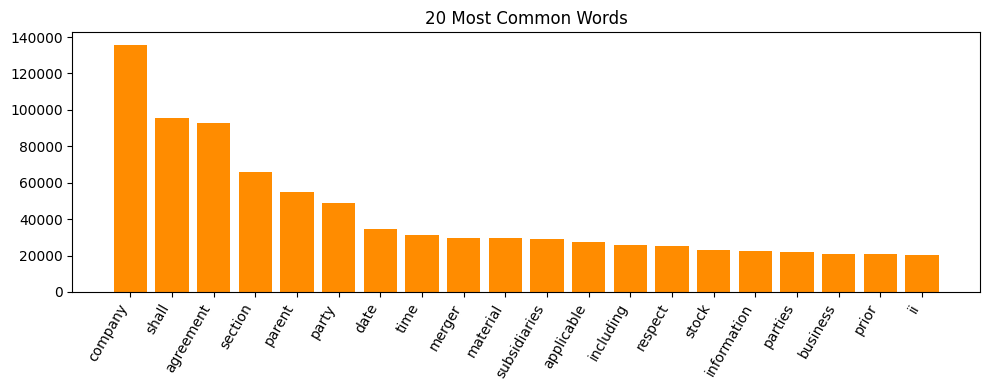

In [8]:
# Find frequency of occurence of words
from collections import Counter

word_counter = Counter()
for doc in documents:
    word_counter.update(doc.metadata["normalized_text"].split())

most_common_20 = word_counter.most_common(20)
least_common_20 = sorted(word_counter.items(), key=lambda kv: (kv[1], kv[0]))[:20]

print(f"Vocabulary size (post stop-word removal): {len(word_counter)}")
print("\n20 most common words:")
for word, count in most_common_20:
    print(f"  {word}: {count}")

print("\n20 least common words:")
for word, count in least_common_20:
    print(f"  {word}: {count}")

words, counts = zip(*most_common_20)
plt.figure(figsize=(10, 4))
plt.bar(words, counts, color="darkorange")
plt.title("20 Most Common Words")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


#### **1.3.3** Analyse the similarity of different documents to each other based on TF-IDF vectors.

Transform some documents to TF-IDF vectors and calculate their similarity matrix using a suitable distance function. If contracts contain duplicate or highly similar clauses, similarity calculation can help detect them.

Identify for the first 10 documents and then for 10 random documents. What do you observe?

TF-IDF matrix shape: (644, 16642)


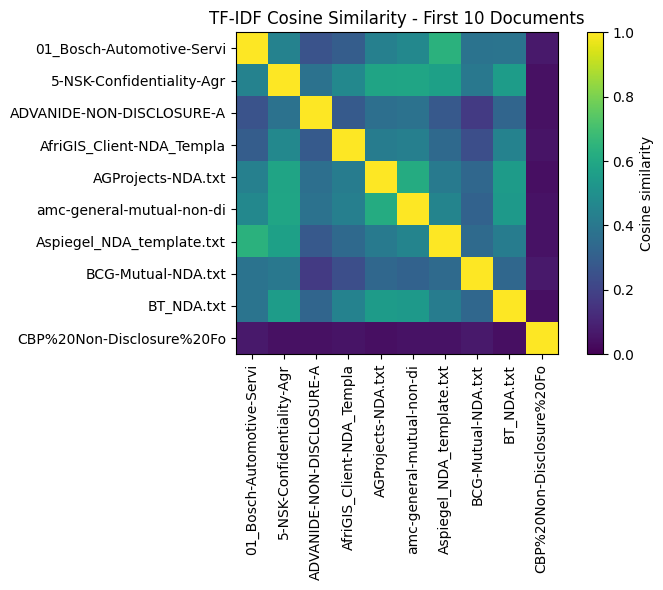

,01_Bosch-Automotive-Servi,5-NSK-Confidentiality-Agr,ADVANIDE-NON-DISCLOSURE-A,AfriGIS_Client-NDA_Templa,AGProjects-NDA.txt,amc-general-mutual-non-di,Aspiegel_NDA_template.txt,BCG-Mutual-NDA.txt,BT_NDA.txt,CBP%20Non-Disclosure%20Fo
01_Bosch-Automotive-Servi,1.000000,0.442957,0.256008,0.296420,0.434784,0.464928,0.638030,0.382628,0.384600,0.069354
5-NSK-Confidentiality-Agr,0.442957,1.000000,0.375558,0.468191,0.585767,0.587715,0.567605,0.399824,0.551893,0.045097
ADVANIDE-NON-DISCLOSURE-A,0.256008,0.375558,1.000000,0.281980,0.365428,0.376104,0.278635,0.171050,0.326554,0.045997
AfriGIS_Client-NDA_Templa,0.296420,0.468191,0.281980,1.000000,0.418373,0.431919,0.341740,0.240951,0.443966,0.054289
AGProjects-NDA.txt,0.434784,0.585767,0.365428,0.418373,1.000000,0.615805,0.407791,0.335192,0.549078,0.042691
amc-general-mutual-non-di,0.464928,0.587715,0.376104,0.431919,0.615805,1.000000,0.450199,0.312907,0.541261,0.047324
Aspiegel_NDA_template.txt,0.638030,0.567605,0.278635,0.341740,0.407791,0.450199,1.000000,0.344806,0.418427,0.050483
BCG-Mutual-NDA.txt,0.382628,0.399824,0.171050,0.240951,0.335192,0.312907,0.344806,1.000000,0.332142,0.067610
BT_NDA.txt,0.384600,0.551893,0.326554,0.443966,0.549078,0.541261,0.418427,0.332142,1.000000,0.039131
CBP%20Non-Disclosure%20Fo,0.069354,0.045097,0.045997,0.054289,0.042691,0.047324,0.050483,0.067610,0.039131,1.000000


In [9]:
# Transform the page contents of documents
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

corpus_texts = [doc.page_content for doc in documents]
doc_labels = [doc.metadata["file_name"] for doc in documents]

tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_texts)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


# Compute similarity scores
def similarity_heatmap(indices, title):
    sub_matrix = tfidf_matrix[indices]
    sim = cosine_similarity(sub_matrix)
    labels = [doc_labels[i][:25] for i in indices]
    sim_df = pd.DataFrame(sim, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    plt.imshow(sim, cmap="viridis", vmin=0, vmax=1)
    plt.colorbar(label="Cosine similarity")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return sim_df


first_10_indices = list(range(10))
first_10_sim_df = similarity_heatmap(first_10_indices, "TF-IDF Cosine Similarity - First 10 Documents")
first_10_sim_df


In [10]:
# create a list of 10 random integers
import random

random.seed(42)
random_10_indices = random.sample(range(len(documents)), 10)
print("Randomly selected document indices:", random_10_indices)
print("Corresponding doc types:", [documents[i].metadata["doc_type"] for i in random_10_indices])


Randomly selected document indices: [114, 25, 281, 250, 228, 142, 104, 558, 89, 604]
Corresponding doc types: ['cuad', 'contractnli', 'cuad', 'cuad', 'cuad', 'cuad', 'cuad', 'maud', 'contractnli', 'maud']


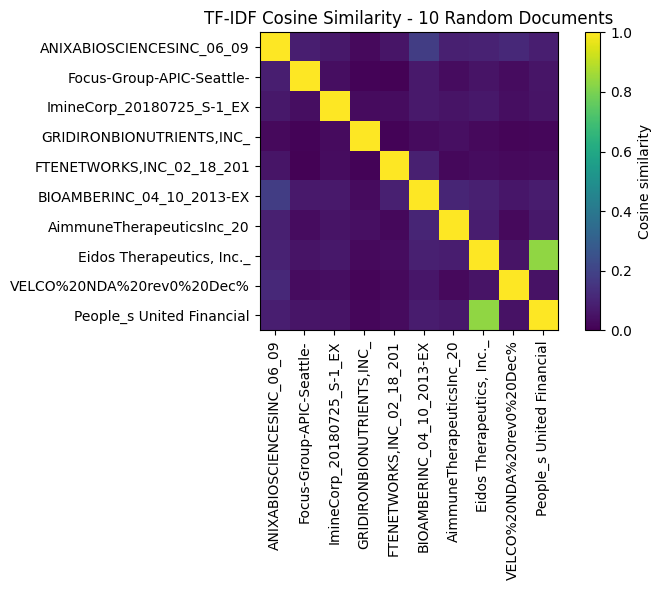

Average pairwise similarity - first 10 (same doc type: contractnli): 0.340
Average pairwise similarity - 10 random documents (mixed types): 0.071

Observation: the first 10 documents all come from the same subfolder (sorted, then loaded folder by folder) and reuse similar NDA boilerplate, so they score much higher on TF-IDF cosine similarity. The random sample mixes NDAs, CUAD clauses, M&A agreements and privacy policies, which share far less vocabulary, so their average pairwise similarity is noticeably lower.


,ANIXABIOSCIENCESINC_06_09,Focus-Group-APIC-Seattle-,ImineCorp_20180725_S-1_EX,"GRIDIRONBIONUTRIENTS,INC_","FTENETWORKS,INC_02_18_201",BIOAMBERINC_04_10_2013-EX,AimmuneTherapeuticsInc_20,"Eidos Therapeutics, Inc._",VELCO%20NDA%20rev0%20Dec%,People_s United Financial
ANIXABIOSCIENCESINC_06_09,1.000000,0.085197,0.062990,0.025995,0.058592,0.183226,0.088141,0.095531,0.116418,0.082933
Focus-Group-APIC-Seattle-,0.085197,1.000000,0.037431,0.011202,0.007561,0.069035,0.031316,0.053460,0.031269,0.057212
ImineCorp_20180725_S-1_EX,0.062990,0.037431,1.000000,0.028178,0.035114,0.069752,0.053787,0.065853,0.038033,0.053596
"GRIDIRONBIONUTRIENTS,INC_",0.025995,0.011202,0.028178,1.000000,0.011064,0.029908,0.039613,0.023603,0.011881,0.018979
"FTENETWORKS,INC_02_18_201",0.058592,0.007561,0.035114,0.011064,1.000000,0.087880,0.020868,0.034006,0.023874,0.028746
BIOAMBERINC_04_10_2013-EX,0.183226,0.069035,0.069752,0.029908,0.087880,1.000000,0.103770,0.087742,0.060922,0.076478
AimmuneTherapeuticsInc_20,0.088141,0.031316,0.053787,0.039613,0.020868,0.103770,1.000000,0.080823,0.027213,0.064819
"Eidos Therapeutics, Inc._",0.095531,0.053460,0.065853,0.023603,0.034006,0.087742,0.080823,1.000000,0.052641,0.835146
VELCO%20NDA%20rev0%20Dec%,0.116418,0.031269,0.038033,0.011881,0.023874,0.060922,0.027213,0.052641,1.000000,0.047241
People_s United Financial,0.082933,0.057212,0.053596,0.018979,0.028746,0.076478,0.064819,0.835146,0.047241,1.000000


In [11]:
# Compute similarity scores for 10 random documents
random_10_sim_df = similarity_heatmap(random_10_indices, "TF-IDF Cosine Similarity - 10 Random Documents")


def mean_offdiag(sim_df):
    values = sim_df.values
    mask = ~np.eye(len(values), dtype=bool)
    return values[mask].mean()


print(f"Average pairwise similarity - first 10 (same doc type: {documents[0].metadata['doc_type']}): {mean_offdiag(first_10_sim_df):.3f}")
print(f"Average pairwise similarity - 10 random documents (mixed types): {mean_offdiag(random_10_sim_df):.3f}")
print(
    "\nObservation: the first 10 documents all come from the same subfolder (sorted, then loaded "
    "folder by folder) and reuse similar NDA boilerplate, so they score much higher on TF-IDF cosine "
    "similarity. The random sample mixes NDAs, CUAD clauses, M&A agreements and privacy policies, "
    "which share far less vocabulary, so their average pairwise similarity is noticeably lower."
)
random_10_sim_df


### **1.4 Document Creation and Chunking**

#### **1.4.1** Perform appropriate steps to split the text into chunks.

In [13]:
# Process files and generate chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter
from urllib.parse import unquote

FILE_SEPARATOR = "\n\n=== END OF FILE ===\n\n"


def friendly_title(file_name: str) -> str:
    """Turn a corpus file name into space-separated words (e.g. 'CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt'
    -> 'CopAcc NDA and ToP Mentors 2.0 2017') so party/entity names are tokenizable by BM25 and embeddings."""
    name = unquote(Path(file_name).stem)
    return re.sub(r"[_\-]+", " ", name).strip()


# 1. Combine all cleaned documents within each folder into a single per-folder
#    Document, while tracking the offset range each source file occupies in the
#    combined text so chunks can still be traced back to their originating file.
combined_documents = {}
file_offset_index = {}  # doc_type -> [(start, end, file_name), ...]

for doc_type in DOC_TYPES:
    folder_docs = [d for d in documents if d.metadata["doc_type"] == doc_type]
    parts = []
    offsets = []
    cursor = 0
    for doc in folder_docs:
        start = cursor
        parts.append(doc.page_content)
        cursor += len(doc.page_content)
        offsets.append((start, cursor, doc.metadata["file_name"]))
        parts.append(FILE_SEPARATOR)
        cursor += len(FILE_SEPARATOR)

    combined_text = "".join(parts)
    combined_documents[doc_type] = Document(
        page_content=combined_text,
        metadata={"doc_type": doc_type, "num_source_files": len(folder_docs)},
    )
    file_offset_index[doc_type] = offsets
    print(f"{doc_type}: combined {len(folder_docs)} files into 1 document ({len(combined_text):,} chars)")


def source_file_for_offset(doc_type: str, offset: int) -> str:
    """Map a character offset in a folder's combined document back to its originating file name."""
    for start, end, file_name in file_offset_index[doc_type]:
        if start <= offset < end:
            return file_name
    return "unknown"


# 2. Split each folder's combined document into chunks, one text splitter
#    invocation per folder so folders are never mixed within a chunk.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
    add_start_index=True,
)

# chunks_by_doc_type feeds section 2.1.2, where each folder's chunks are
# embedded into their own separate vector DB.
chunks_by_doc_type = {}
for doc_type, combined_doc in combined_documents.items():
    splits = text_splitter.split_documents([combined_doc])
    for i, chunk in enumerate(splits):
        start_index = chunk.metadata.get("start_index", 0)
        source_file = source_file_for_offset(doc_type, start_index)
        chunk.metadata["source_file"] = source_file
        chunk.metadata["chunk_id"] = f"{doc_type}_{i}"
        header = f"[Source: {doc_type} - {friendly_title(source_file)}]"
        chunk.page_content = f"{header}\n{chunk.page_content}"
    chunks_by_doc_type[doc_type] = splits
    print(f"{doc_type}: {len(splits)} chunks")

all_chunks = [chunk for chunks in chunks_by_doc_type.values() for chunk in chunks]
print(f"\nTotal chunks across all folders: {len(all_chunks)}")
print("\nSample chunk metadata:", all_chunks[0].metadata)
print("Sample chunk text:\n", all_chunks[0].page_content[:300])


contractnli: combined 93 files into 1 document (985,065 chars)
cuad: combined 431 files into 1 document (21,630,547 chars)
maud: combined 117 files into 1 document (39,862,559 chars)
privacy_qa: combined 3 files into 1 document (56,215 chars)
contractnli: 1502 chunks
cuad: 32021 chunks
maud: 65101 chunks
privacy_qa: 73 chunks

Total chunks across all folders: 98697

Sample chunk metadata: {'doc_type': 'contractnli', 'num_source_files': 93, 'start_index': 0, 'source_file': '01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'chunk_id': 'contractnli_0'}
Sample chunk text:
 [Source: contractnli - 01 Bosch Automotive Service Solutions Mutual Non Disclosure Agreement 7 12 17]
MUTUAL NON-DISCLOSURE AGREEMENT
Between
AND
Subject Matter:
Effective Date of Agreement: Period , 2017
for Exchange of Information: , 2017 to
Period of Confidentiality:
THIS AGREEMENT is made as of 


## **2. Vector Database and RAG Chain Creation**

### **2.1 Vector Embedding and Vector Database Creation** 

#### **2.1.1** Initialise an embedding function for loading the embeddings into the vector database.

Initialise a function to transform the text to vectors using an embedding model. You can also use this function to transform during vector DB creation itself.

In [14]:
# Fetch your API Key as an environment variable (or load it directly if variable naming is conventional)
from dotenv import load_dotenv
load_dotenv()

# OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
# if not OPENAI_API_KEY:
#     raise EnvironmentError(
#         "OPENAI_API_KEY is not set. Export it as an environment variable before running "
#         "the embedding/generation cells (do not hardcode it in the notebook)."
#     )


True

In [15]:
# Initialise an embedding function
from langchain_openai import OpenAIEmbeddings

EMBEDDING_MODEL = "text-embedding-3-small"
embedding_function = OpenAIEmbeddings(model=EMBEDDING_MODEL)


#### **2.1.2** Load the embeddings to a vector database.

Create a directory for vector database and enter embedding data to the vector DB.

In [16]:
# Add Chunks to vector DB
from langchain_chroma import Chroma

VECTOR_DB_ROOT = Path("vector_db")
VECTOR_DB_ROOT.mkdir(exist_ok=True)

# One separate, persisted Chroma collection per corpus folder / doc_type
vector_dbs = {}
for doc_type in DOC_TYPES:
    persist_dir = VECTOR_DB_ROOT / doc_type
    collection_name = f"legal_{doc_type}"

    # If a persisted DB already exists for this doc_type, load it instead of rebuilding
    if persist_dir.exists() and any(persist_dir.iterdir()):
        vector_dbs[doc_type] = Chroma(
            collection_name=collection_name,
            embedding_function=embedding_function,
            persist_directory=str(persist_dir),
        )
        print(f"{doc_type}: loaded existing vector DB <- {persist_dir}")
    else:
        vector_dbs[doc_type] = Chroma.from_documents(
            documents=chunks_by_doc_type[doc_type],
            embedding=embedding_function,
            collection_name=collection_name,
            persist_directory=str(persist_dir),
        )
        print(f"{doc_type}: added {len(chunks_by_doc_type[doc_type])} chunks -> {persist_dir}")

contractnli: loaded existing vector DB <- vector_db\contractnli
cuad: loaded existing vector DB <- vector_db\cuad
maud: loaded existing vector DB <- vector_db\maud
privacy_qa: loaded existing vector DB <- vector_db\privacy_qa


### **2.2 Create RAG Chain** 

#### **2.2.1** Form the complete RAG pipeline. 

You can either create a chain or directly the pipeline

In [17]:
for doc_type, db in vector_dbs.items():
    print(doc_type, db)

contractnli <langchain_chroma.vectorstores.Chroma object at 0x0000025C0AE98C10>
cuad <langchain_chroma.vectorstores.Chroma object at 0x0000025C0A8B79D0>
maud <langchain_chroma.vectorstores.Chroma object at 0x0000025C0A904350>
privacy_qa <langchain_chroma.vectorstores.Chroma object at 0x0000025C0A906690>


In [18]:
# Create a RAG chain
from typing import List, Literal

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from pydantic import BaseModel, Field

LLM_MODEL = "gpt-4o-mini"
TOP_K = 8

Open_ai_llm = ChatOpenAI(model=LLM_MODEL, temperature=0)

# Hybrid retriever per collection: dense (semantic) search combined with BM25

retrievers = {}
for doc_type, db in vector_dbs.items():
    vector_retriever = db.as_retriever(search_kwargs={"k": TOP_K})
    bm25_retriever = BM25Retriever.from_documents(chunks_by_doc_type[doc_type])
    bm25_retriever.k = TOP_K
    retrievers[doc_type] = EnsembleRetriever(
        retrievers=[vector_retriever, bm25_retriever], weights=[0.5, 0.5]
    )

DOC_TYPE_DESCRIPTIONS = {
    "contractnli": "Non-disclosure and confidentiality agreements (NDAs).",
    "cuad": "Commercial contracts with annotated legal clauses (CUAD).",
    "maud": "Merger and acquisition agreements (MAUD).",
    "privacy_qa": "Privacy policy question-answering documents.",
}


# --- Router chain: classify which vector DB(s) a query needs ---
class RouteQuery(BaseModel):
    """The legal document collection(s) needed to answer the user's question."""

    datasources: List[Literal["contractnli", "cuad", "maud", "privacy_qa"]] = Field(
        description=(
            "Every collection required to answer the question. A question can need "
            "more than one collection at once, e.g. comparing an NDA clause to a "
            "CUAD clause - include all of them, not just the single best match."
        )
    )


router_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a query router for a legal-document RAG system with four collections:\n"
            + "\n".join(f"- {k}: {v}" for k, v in DOC_TYPE_DESCRIPTIONS.items())
            + "\n\nGiven the user's question, choose every collection needed to answer it.",
        ),
        ("human", "{question}"),
    ]
)
router_chain = router_prompt | Open_ai_llm.with_structured_output(RouteQuery)


def route_query(question: str) -> List[str]:
    """Return the doc_types relevant to the question; fall back to searching all 4 if routing fails or is empty."""
    try:
        result = router_chain.invoke({"question": question})
        datasources = list(dict.fromkeys(result.datasources))  # dedupe, preserve order
    except Exception as exc:
        logger.warning("Router failed (%s); falling back to searching all collections.", exc)
        datasources = []
    return datasources or DOC_TYPES


def retrieve_from_routes(question: str, datasources: List[str]):
    """Retrieve from every routed vector DB and merge the results (handles single- or multi-DB routing)."""
    retrieved = []
    for doc_type in datasources:
        retrieved.extend(retrievers[doc_type].invoke(question))
    return retrieved


def format_docs(docs) -> str:
    # Each chunk's page_content already starts with a "[Source: ...]" header
    # (added at chunking time), so there's no need to re-prefix it here.
    return "\n\n".join(d.page_content for d in docs)


ANSWER_PROMPT = ChatPromptTemplate.from_template(
    "You are a legal assistant. Answer the question using ONLY the context below, which was "
    "retrieved from the routed legal-document collection(s): {datasources}. "
    "If the context does not contain the answer, say you don't know.\n\n"
    "Context:\n{context}\n\n"
    "Question: {question}\n\n"
    "Answer:"
)


def build_chain_inputs(inputs: dict) -> dict:
    question = inputs["question"]
    datasources = route_query(question)
    docs = retrieve_from_routes(question, datasources)
    return {
        "question": question,
        "datasources": ", ".join(datasources),
        "context": format_docs(docs),
        "source_documents": docs,
    }


# route -> multi-DB retrieve -> generate, while keeping the source documents alongside the answer
rag_chain = RunnableLambda(build_chain_inputs) | RunnablePassthrough.assign(
    answer=(ANSWER_PROMPT | Open_ai_llm | StrOutputParser())
)


#### **2.2.2** Create a function to generate answer for asked questions.

Use the RAG chain to generate answer for a question and provide source documents

In [19]:
# Create a function for question answering
def answer_question(question: str) -> dict:
    """Run the routed RAG chain and return the answer along with the source documents used."""
    result = rag_chain.invoke({"question": question})
    sources = [
        {
            "doc_type": doc.metadata.get("doc_type"),
            "source_file": doc.metadata.get("source_file"),
            "chunk_id": doc.metadata.get("chunk_id"),
            "snippet": doc.page_content[:200],
        }
        for doc in result["source_documents"]
    ]
    return {
        "question": question,
        "datasources_used": result["datasources"],
        "answer": result["answer"],
        "source_documents": sources,
    }

def print_answer(result: dict) -> None:
    """Pretty-print the output of answer_question() instead of dumping the raw dict."""
    print(f"Question: {result['question']}\n")
    print(f"Datasources used: {result['datasources_used']}\n")
    print(f"Answer:\n{result['answer']}\n")
    print(f"Sources ({len(result['source_documents'])}):")
    for i, src in enumerate(result["source_documents"], start=1):
        print(f"  {i}. [{src['doc_type']}] {src['source_file']} (chunk_id={src['chunk_id']})")
        print(f"     \"{src['snippet'].strip()}...\"")


In [20]:
# Example question
ans = answer_question(question ="Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?")
print_answer(ans)


INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Question: Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?

Datasources used: contractnli

Answer:
Yes, the document indicates that the Agreement does not grant the Receiving Party any rights to the Confidential Information, except for the limited right to review, assess, and help develop the Participants' Ideas.

Sources (15):
  1. [contractnli] CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt (chunk_id=contractnli_223)
     "[Source: contractnli - CopAcc NDA and ToP Mentors 2.0 2017]
14 Miscellaneous
This Agreement shall be binding upon Organiser and Mentor, and their successors and assigns. This Agreement contains the en..."
  2. [contractnli] CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt (chunk_id=contractnli_216)
     "[Source: contractnli - CopAcc NDA and ToP Mentors 2.0 2017]
Mentor shall not use any Confidential Information for any purpose except to

## **3. RAG Evaluation** 

### **3.1 Evaluation and Inference** 

#### **3.1.1** Extract all the questions and all the answers/ground truths from the benchmark files.

Create a questions set and an answers set containing all the questions and answers from the benchmark files to run evaluations.

In [21]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set
import json

BENCHMARK_DIR = Path("rag_legal/benchmarks")
BENCHMARK_FILES = {
    "contractnli": "contractnli.json",
    "cuad": "cuad.json",
    "maud": "maud.json",
    # no privacy_qa.json benchmark file exists for this corpus subfolder
}

eval_examples = []
for doc_type, file_name in BENCHMARK_FILES.items():
    with open(BENCHMARK_DIR / file_name, encoding="utf-8") as f:
        benchmark = json.load(f)
    for test in benchmark["tests"]:
        snippets = test["snippets"]
        eval_examples.append(
            {
                "doc_type": doc_type,
                "question": test["query"],
                "ground_truth": " ".join(s["answer"] for s in snippets),
                "source_files": sorted({s["file_path"] for s in snippets}),
            }
        )

questions = [ex["question"] for ex in eval_examples]
ground_truths = [ex["ground_truth"] for ex in eval_examples]

print(f"Total benchmark questions: {len(eval_examples)}")
for doc_type in BENCHMARK_FILES:
    count = sum(1 for ex in eval_examples if ex["doc_type"] == doc_type)
    print(f"  {doc_type}: {count} questions")

print("\nSample question/ground-truth pair:")
print(eval_examples[0])


Total benchmark questions: 6695
  contractnli: 977 questions
  cuad: 4042 questions
  maud: 1676 questions

Sample question/ground-truth pair:
{'doc_type': 'contractnli', 'question': 'Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?', 'ground_truth': 'Any and all proprietary rights, including but not limited to rights to and in inventions, patent rights, utility models, copyrights, trademarks and trade secrets, in and to any Confidential Information shall be and remain with the Participants respectively, and Mentor shall not have any right, license, title or interest in or to any Confidential Information, except the limited right to review, assess and help develop such Confidential Information in connection with the Copernicus Accelerator 2017.', 'source_files': ['contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt']}


#### **3.1.2** Create a function to evaluate the generated answers and retrieved contexts.

Evaluate the responses with *Ragas*. Additionally check the retrieval quality using 2 retrieval-driven metrics.

In [ ]:
# Function to evaluate the RAG pipeline
import sys
import types

if "langchain_community.chat_models.vertexai" not in sys.modules:
    _vertexai_stub = types.ModuleType("langchain_community.chat_models.vertexai")
    _vertexai_stub.ChatVertexAI = type("ChatVertexAI", (), {})
    sys.modules["langchain_community.chat_models.vertexai"] = _vertexai_stub

from ragas import evaluate as ragas_evaluate
from ragas.dataset_schema import EvaluationDataset
from ragas.metrics import AnswerRelevancy, ContextPrecision, ContextRecall, Faithfulness
from ragas.llms import LangchainLLMWrapper

judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
judge_embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

def hit_rate(expected_sources: List[str], retrieved_sources: List[str]) -> float:
    """1.0 if at least one retrieved chunk came from an expected source file, else 0.0."""
    return float(bool(set(expected_sources) & set(retrieved_sources)))


def mean_reciprocal_rank(expected_sources: List[str], retrieved_sources: List[str]) -> float:
    """1 / rank of the first retrieved chunk from an expected source file, else 0."""
    for rank, source in enumerate(retrieved_sources, start=1):
        if source in expected_sources:
            return 1.0 / rank
    return 0.0


def evaluate_rag(examples: List[dict]) -> dict:
    ragas_rows = []
    hit_rates, mrrs = [], []

    for ex in examples:
        result = rag_chain.invoke({"question": ex["question"]})
        retrieved_docs = result["source_documents"]
        retrieved_contexts = [d.page_content for d in retrieved_docs]
        retrieved_sources = [
            f"{d.metadata.get('doc_type')}/{d.metadata.get('source_file')}" for d in retrieved_docs
        ]

        ragas_rows.append(
            {
                "user_input": ex["question"],
                "response": result["answer"],
                "retrieved_contexts": retrieved_contexts,
                "reference": ex["ground_truth"],
            }
        )
        hit_rates.append(hit_rate(ex["source_files"], retrieved_sources))
        mrrs.append(mean_reciprocal_rank(ex["source_files"], retrieved_sources))

    ragas_dataset = EvaluationDataset.from_list(ragas_rows)
    ragas_result = ragas_evaluate(
        dataset=ragas_dataset,
        metrics=[Faithfulness(), AnswerRelevancy(), ContextPrecision(), ContextRecall()],
        llm=judge_llm,
        embeddings=judge_embeddings,
    )

    return {
        "ragas_result": ragas_result,
        "hit_rate": float(np.mean(hit_rates)),
        "mrr": float(np.mean(mrrs)),
        "hit_rates": hit_rates,
        "mrrs": mrrs,
    }


C:\Users\itssu\AppData\Local\Temp\ipykernel_55020\3178296773.py:16: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import AnswerRelevancy, ContextPrecision, ContextRecall, Faithfulness
C:\Users\itssu\AppData\Local\Temp\ipykernel_55020\3178296773.py:16: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import AnswerRelevancy, ContextPrecision, ContextRecall, Faithfulness
C:\Users\itssu\AppData\Local\Temp\ipykernel_55020\3178296773.py:16: DeprecationWarning: Importing ContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from 

#### **3.1.3** Draw inferences by evaluating answers to questions.

To save time and computing power, you can just run the evaluation on 10 randomly sampled questions.

In [26]:
# Evaluate the RAG pipeline
random.seed(42)
sample_size = min(10, len(eval_examples))
sample_examples = random.sample(eval_examples, sample_size)

# Save question, response, retrieved context, ground truth, and all metrics to CSV
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Running evaluation on {sample_size} randomly sampled questions...\n")
for ex in sample_examples:
    print(f"  [{ex['doc_type']}] {ex['question'][:80]}")

eval_output = evaluate_rag(sample_examples)

print("\nRagas metrics (mean over sample):")
print(eval_output["ragas_result"])

print("\nRetrieval metrics:")
print(f"  Hit Rate: {eval_output['hit_rate']:.3f}")
print(f"  MRR:      {eval_output['mrr']:.3f}")

ragas_df = eval_output["ragas_result"].to_pandas()
ragas_df

results_df = ragas_df.copy()
results_df["hit_rate"] = eval_output["hit_rates"]
results_df["mrr"] = eval_output["mrrs"]

results_csv_path = RESULTS_DIR / "rag_evaluation_results.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"Saved evaluation results to {results_csv_path}")

results_df



Running evaluation on 10 randomly sampled questions...

  [maud] Consider the Acquisition Agreement between Parent "Tyler Technologies, Inc." and
  [contractnli] Consider the Mutual Non-Disclosure Agreement between Inventor and Product Develo
  [contractnli] Consider Inaturals's Non-Disclosure Agreement; Does the document allow the Recei
  [maud] Consider the Acquisition Agreement between Parent "Unifrax Holding Co." and Targ
  [cuad] Consider the Business Development Agreement between Liquidmetal Technologies, In
  [cuad] Consider the Affiliate Agreement between The TUBE Music Network, Inc. and Tribun
  [cuad] Consider the Co-Branding Agreement between VerticalNet, Inc. and Impresse Corpor
  [cuad] Consider the Recipe Development Agreement between Reed's, Inc. and B C Marketing
  [maud] Consider the Acquisition Agreement between Parent "VENTAS, INC." and Target "NEW
  [contractnli] Consider the Mutual Non-Disclosure Agreement between Boston Consulting Group and


INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 


Ragas metrics (mean over sample):
{'faithfulness': 0.6667, 'answer_relevancy': 0.4823, 'context_precision': 0.7610, 'context_recall': 0.9667}

Retrieval metrics:
  Hit Rate: 1.000
  MRR:      0.920
Saved evaluation results to results\rag_evaluation_results.csv


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall,hit_rate,mrr
0,Consider the Acquisition Agreement between Par...,"[[Source: maud - NIC Inc. Tyler Technologies, ...",“Tyler Material Adverse Effect” means any Effe...,“NIC Material Adverse Effect” means any Effect...,1.000000,0.692966,1.000000,1.000000,1.0,1.0
1,Consider the Mutual Non-Disclosure Agreement b...,[[Source: contractnli - Mutual Non Disclosure ...,"Yes, the document allows the Receiving Party t...","Confidential Information shall not, however, i...",1.000000,0.780539,1.000000,1.000000,1.0,1.0
2,Consider Inaturals's Non-Disclosure Agreement;...,[[Source: contractnli - Inaturals NDA]\n1. A p...,"Yes, the Inaturals Non-Disclosure Agreement al...",The Recipient will communicate such informatio...,0.666667,0.884461,0.874195,1.000000,1.0,1.0
3,Consider the Acquisition Agreement between Par...,[[Source: maud - Retail Properties of America ...,I don't know.,(b) Termination Fee. (ii) ...,0.000000,0.000000,0.619267,1.000000,1.0,0.2
4,Consider the Business Development Agreement be...,[[Source: cuad - LiquidmetalTechnologiesInc 20...,"Yes, the licenses granted under the contract i...",Eutectix hereby grants to Liquidmetal a fully-...,1.000000,0.561916,0.869883,0.666667,1.0,1.0
5,Consider the Affiliate Agreement between The T...,[[Source: cuad - TubeMediaCorp 20060310 8 K EX...,The expiration date of the contract is March 3...,"The ""Initial Term"" shall commence upon the Eff...",1.000000,0.553886,0.797279,1.000000,1.0,1.0
6,Consider the Co-Branding Agreement between Ver...,[[Source: cuad - ImpresseCorp 20000322 S 1A EX...,The governing law for this contract shall be t...,This Agreement shall be governed by and interp...,0.500000,0.604922,0.375000,1.000000,1.0,1.0
7,Consider the Recipe Development Agreement betw...,[[Source: cuad - ReedsInc 20191113 10 Q EX 10....,I don't know.,EXCEPT WITH RESPECT TO THE INDEMNIFICATION OBL...,0.000000,0.000000,0.693519,1.000000,1.0,1.0
8,Consider the Acquisition Agreement between Par...,[[Source: maud - New Senior Investment Group I...,The context does not provide specific informat...,Section 6.2 Conditions to Obligations...,0.500000,0.000000,0.619103,1.000000,1.0,1.0
9,Consider the Mutual Non-Disclosure Agreement b...,[[Source: contractnli - BCG Mutual NDA]\nc. No...,"Yes, the document indicates that the Agreement...",This agreement does not grant any implied inte...,1.000000,0.743870,0.761424,1.000000,1.0,1.0


## **4. Conclusion** 

### **4.1 Conclusions and insights** 

#### **4.1.1** Conclude with the results here. Include the insights gained about the data, model pipeline, the RAG process and the results obtained.

### Insights from the Data

- The corpus is heavily imbalanced across document types: after chunking, `maud` (65,101 chunks) and `cuad` (32,021 chunks) dwarf `contractnli` (1,502) and `privacy_qa` (73). This imbalance matters for retrieval — the router/collection split (one Chroma collection per `doc_type`) exists specifically to stop the huge `maud`/`cuad` collections from drowning out the smaller ones in a shared vector index.
- TF-IDF similarity analysis showed same-folder documents (e.g. NDAs) score far higher pairwise cosine similarity than a random cross-folder sample, confirming heavy boilerplate reuse within a document type (standard NDA/MAUD clause language) and clear vocabulary separation *between* types — this is what makes doc-type routing a sound design choice in the first place, and also why BM25 was added alongside semantic search: near-identical boilerplate across many files makes embeddings alone insufficient to tell *which* file a clause came from.

### Insights from the Pipeline

- **Hybrid retrieval (dense + BM25) was necessary, not optional.** Legal boilerplate repeats near-verbatim across many source files, so semantic similarity alone frequently can't distinguish the correct source. BM25 recovers exact matches on named entities (parties, contract names) that often only appear once, in the "[Source: ...]" header prepended at chunking time.
- **Query routing trades recall for precision/cost.** Classifying which collection(s) to search before retrieving keeps searches scoped and cheap.


### Insights from the Evaluation

On a 10-question random sample: **Faithfulness 0.667, Answer Relevancy 0.482, Context Precision 0.761, Context Recall 0.967, Hit Rate 1.000, MRR 0.920.**

At face value the low faithfulness/relevancy scores look like a generation problem. Row-level inspection of `results/rag_evaluation_results.csv` tells a different story: **3 of the 10 examples scored 0/0 because the model correctly responded "I don't know"** rather than hallucinating — Ragas scores a non-committal answer identically to a wrong one (0 faithfulness, 0 relevancy), which is a blind spot in the metric, not a failure of the pipeline's honesty. Excluding those three refusals, the remaining seven answered questions average **faithfulness ≈ 0.88** and **answer relevancy ≈ 0.69** — a materially better picture of actual answer quality.

The refusals themselves trace back to a retrieval gap the aggregate `Hit Rate = 1.000` masked: hit rate/MRR here are computed at **file level** (did any retrieved chunk come from the correct source file?), not clause level (did a retrieved chunk actually contain the answer span?). On large files (`maud`, `cuad` chunked at 1000 characters), retrieving *a* chunk from the right file is a much weaker guarantee than retrieving *the* chunk with the answer — which is exactly what happened on the three refused questions.

### Limitations and Recommended Next Steps

- Evaluate on a larger sample than 10 questions before drawing firm conclusions — this sample size is appropriate for cost/time control during development, not for statistically confident metric estimates.
- Retrieval metrics should be tightened to check span-level overlap (using the benchmark's `span` field and each chunk's `start_index`) rather than filename match, to make "did retrieval actually find the clause" measurable directly instead of inferred from downstream refusals.
- Increasing `TOP_K`, chunk overlap, and/or adding a reranking stage over a wider candidate pool are the most direct ways to close the retrieval gap responsible for the observed refusals.
- With those retrieval improvements, faithfulness and relevancy on the *answered* subset (already ≈0.88 / ≈0.69) are a more realistic target for the whole sample, since the pipeline's generation behavior — grounding answers in context and declining when the context is insufficient — is already appropriate for a legal-assistant use case where hallucination is costlier than an honest "I don't know."

### Business Takeaway

For the stated use cases (faster legal research, contract clause extraction, compliance monitoring), the pipeline's core behavior — refusing to answer rather than fabricating a legal claim — is the right default for a domain where an incorrect answer carries real risk. The main gap before this is production-ready is retrieval recall at the clause level, not generation faithfulness: once the correct passage is reliably surfaced, the generation step already handles it well.
